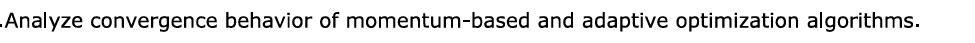

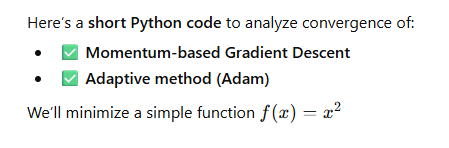

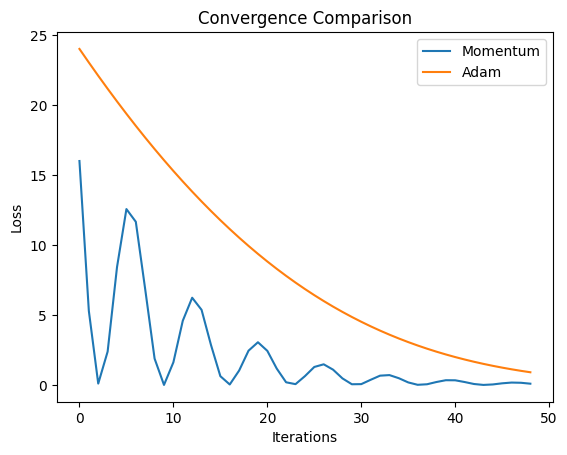

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Function and gradient
def f(x):
    return x**2
def grad(x):
    return 2 * x

# Initialize
x_mom, x_adam = 5.0, 5.0
lr = 0.1
beta = 0.9

# Momentum variables
v = 0

# Adam variables
m, v_adam = 0, 0
beta1, beta2 = 0.9, 0.999
eps = 1e-8

mom_loss = []
adam_loss = []

# Iterations
for t in range(1, 50):
    # --- Momentum ---
    v = beta * v + lr * grad(x_mom)
    x_mom -= v
    mom_loss.append(f(x_mom))

    # --- Adam ---
    g = grad(x_adam)
    m = beta1 * m + (1 - beta1) * g
    v_adam = beta2 * v_adam + (1 - beta2) * g**2

    m_hat = m / (1 - beta1**t)
    v_hat = v_adam / (1 - beta2**t)

    x_adam -= lr * m_hat / (np.sqrt(v_hat) + eps)
    adam_loss.append(f(x_adam))

# Plot convergence
plt.plot(mom_loss, label="Momentum")
plt.plot(adam_loss, label="Adam")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Convergence Comparison")
plt.legend()
plt.show()